In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.style.use("seaborn-v0_8")


In [2]:
# Load ML features
X_features = np.load("../data/processed/ml_features_400.npy")

# Load labels (must use allow_pickle=True)
data = np.load("../data/processed/processed_400_timesteps.npz", allow_pickle=True)
y = data["y"]

print("Feature matrix shape:", X_features.shape)
print("Labels shape:", y.shape)


Feature matrix shape: (10000, 1200)
Labels shape: (10000,)


In [3]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")
for cls, enc in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{cls} → {enc}")


Label mapping:
AR → 0
PF → 1


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # preserves class imbalance
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 8000
Testing samples: 2000


In [5]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)


In [6]:
print("Logistic Regression Performance\n")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_lr, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred_lr, average="weighted"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))


Logistic Regression Performance

Accuracy: 0.9915
Precision: 0.9915004915004916
Recall: 0.9915
F1 Score: 0.9914999978749995

Classification Report:

              precision    recall  f1-score   support

          AR       0.99      0.99      0.99      1000
          PF       0.99      0.99      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [8]:
print("Random Forest Performance\n")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred_rf, average="weighted"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))


Random Forest Performance

Accuracy: 0.999
Precision: 0.999001996007984
Recall: 0.999
F1 Score: 0.998999998999999

Classification Report:

              precision    recall  f1-score   support

          AR       1.00      1.00      1.00      1000
          PF       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [9]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# Train (example)
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_features, y)

# Save model
joblib.dump(rf_model, "../outputs/models/random_forest_model.pkl")
print("Random Forest model saved")


Random Forest model saved


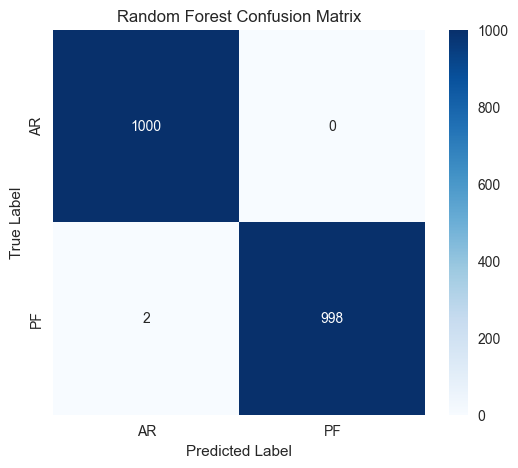

In [10]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")
plt.show()


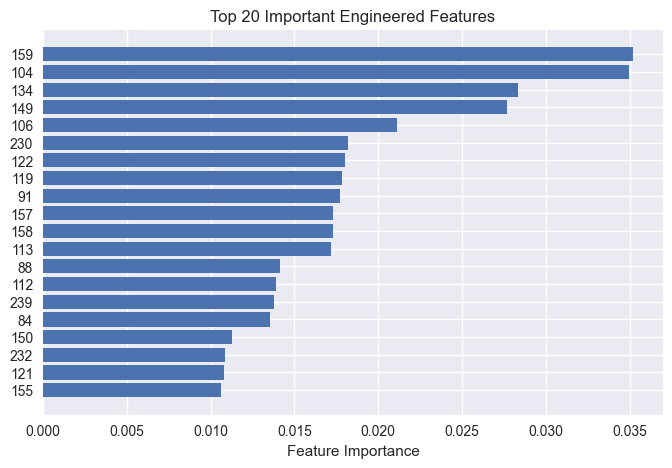

In [11]:
importances = rf.feature_importances_

# Get top 20 important features
top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(8,5))
plt.barh(range(len(top_idx)), importances[top_idx])
plt.yticks(range(len(top_idx)), top_idx)
plt.xlabel("Feature Importance")
plt.title("Top 20 Important Engineered Features")
plt.show()


### Machine Learning Model Summary

- Models trained:
  - Logistic Regression (baseline)
  - Random Forest (ensemble)
- Input features: 1200 engineered numerical features
- Train–test split: 80% / 20%
- Class imbalance handled using class weights
- Random Forest achieved better performance than Logistic Regression

These ML models serve as baseline benchmarks for comparison
with deep learning models in later stages.
